# Classical Monte Carlo benchmark for quantum CVA

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import time

from benchmark_utils import P0, build_survival_from_cds


### CVA of a  *single underlying Equity-Forward*

Specifications of the estimation using classical Monte Carlo methods: 

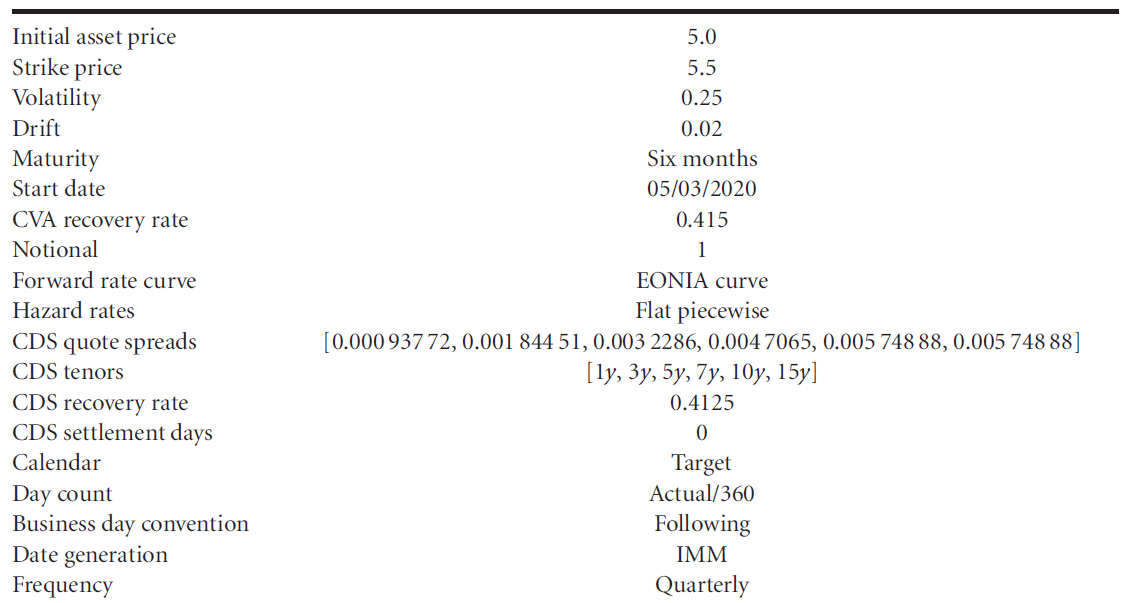

In [2]:
# =============================
# Simulation parameters
# =============================
S0 = 5.0
K = 5.5
sigma = 0.25
mu = 0.02
r = -0.54/100 # approx flat curve from market data

R_cva = 0.415
R_cds = 0.4125
LGD = 1.0 - R_cva

T = 184/360
N_paths = 100_000
M = 4
t = np.linspace(0.0, T, M+1)

rng = np.random.default_rng()

# Flat-curve discount function for CDS bootstrap
P0_flat = lambda u: P0(u, r)

# CDS specifications
cds_tenors_years = [1, 3, 5, 7, 10, 15]
cds_spreads = [
    0.00093772,
    0.00184451,
    0.0032286,
    0.0047065,
    0.00574888,
    0.00574888
]

Default probabilities are obtained by calibrating a piecewise-constant hazard rate function to market CDS par spreads. The bootstrapping procedure does not compute survival probabilities directly; instead, it determines the hazard rates from which survival and default probabilities are subsequently derived.

In the paper, the hazard rate is assumed to be constant between consecutive CDS maturities:
$$
\lambda(t) = \lambda_i \quad \text{for } t \in (T_{i-1}, T_i],
$$
where $\{T_i\}$ denote the CDS maturities. Given this (piecewise) specification, the survival probability admits the representation
$$
S(t) = \exp\!\left(-\int_0^t \lambda(s)\,ds\right)
= \exp\!\left(-\sum_{j=1}^{i-1} \lambda_j (T_j-T_{j-1}) - \lambda_i (t-T_{i-1})\right),
\qquad t \in (T_{i-1},T_i].
$$

For a CDS with maturity $T_i$ and market par spread $s_i$, the no-arbitrage condition requires the contract to have zero value at inception. This implies that the present value of the premium leg equals the present value of the protection leg:
$$
\mathrm{PV}_{\mathrm{premium}}(T_i;\lambda_1,\dots,\lambda_i)
=
\mathrm{PV}_{\mathrm{protection}}(T_i;\lambda_1,\dots,\lambda_i).
$$

Assuming quarterly payments with accrual fraction $\Delta t = 0.25$, the present value of the premium leg (without accrual on default) can be written as
$$
\mathrm{PV}_{\mathrm{premium}}(T_i)
=
\sum_{k=1}^{N_i}
s_i \, \Delta t \, P(0,t_k)\, S(t_k),
$$
where $t_k = k\Delta t$ and $N_i = T_i/\Delta t$. Each survival probability $S(t_k)$ depends explicitly on the hazard rates $\lambda_1,\dots,\lambda_i$, and in particular on $\lambda_i$ for payment dates beyond $T_{i-1}$.

The present value of the protection leg is given by
$$
\mathrm{PV}_{\mathrm{protection}}(T_i)
=
(1-R_{\mathrm{CDS}})
\sum_{k=1}^{N_i}
P(0,t_k)
\big(S(t_{k-1}) - S(t_k)\big),
$$
where $R_{\mathrm{CDS}}$ denotes the recovery rate. The term $S(t_{k-1}) - S(t_k)$ represents the probability of default in the interval $(t_{k-1},t_k]$ and is therefore a direct function of the hazard rates.

For a given maturity $T_i$, the hazard rates $\lambda_1,\dots,\lambda_{i-1}$ are already fixed from previous steps of the bootstrap. The equality between the premium and protection legs thus defines a single nonlinear equation in the unknown $\lambda_i$:
$$
\sum_{k=1}^{N_i}
s_i \, \Delta t \, P(0,t_k)\, S(t_k;\lambda_1,\dots,\lambda_i)
=
(1-R_{\mathrm{CDS}})
\sum_{k=1}^{N_i}
P(0,t_k)
\big(S(t_{k-1};\lambda_1,\dots,\lambda_i) - S(t_k;\lambda_1,\dots,\lambda_i)\big).
$$

This equation is solved numerically, typically using a root-finding algorithm such as bisection or Newton’s method. For each trial value of $\lambda_i$, the survival probabilities are computed from the exponential form above, the two legs are evaluated on the payment grid, and the pricing error is updated until convergence. Once $\lambda_i$ is determined, it is held fixed and the procedure proceeds to the next CDS maturity.

The output of the bootstrap is the set of calibrated hazard rates $\{\lambda_i\}$. From these, the survival curve and the associated default probabilities are obtained as
$$
S(t) = \exp\!\left(-\int_0^t \lambda(s)\,ds\right),
\qquad
q(t_{k-1},t_k) = S(t_{k-1}) - S(t_k),
$$
which are the quantities subsequently used in the CVA computation.

In [3]:
# Bootstrap survival curve
_, _, survival_curve, q_interval = build_survival_from_cds(
    P0=P0_flat,
    tenors=cds_tenors_years,
    spreads=cds_spreads,
    R_cds=R_cds,
    pay_freq=4
)

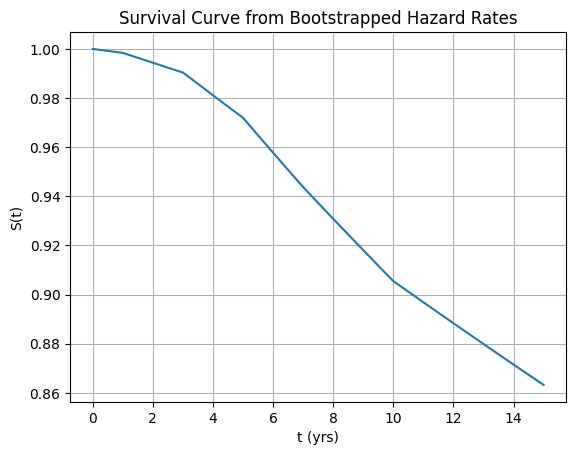

In [4]:
# Plot survival curve
ts = np.linspace(0.0, 15.0, 300)
Ss = [survival_curve(t) for t in ts] 
plt.plot(ts, Ss, label='Survival Probability S(t)')
plt.xlabel('t (yrs)')
plt.ylabel('S(t)')
plt.title('Survival Curve from Bootstrapped Hazard Rates')
plt.grid()

### 2.1 Classical Benchmark using continuous underlying distribution

The CVA is estimated by Monte Carlo simulation using a time-discretized approximation of the continuous-time CVA integral. The underlying asset price is simulated under a lognormal dynamics, and exposures are evaluated on a finite time grid $\{t_i\}_{i=1}^M$.

At each time $t_i$, the simulated underlying price along path $k$ is
$$
S^{(k)}(t_i)
=
S_0 \exp\!\left((\mu - \tfrac{1}{2}\sigma^2)t_i + \sigma \sqrt{t_i}\,Z_i^{(k)}\right),
\qquad k=1,\dots,N.
$$

The corresponding positive exposure is
$$
[V^{(k)}(t_i)]^+
=
\max\!\left(S^{(k)}(t_i) - K\,P(t_i,T),\,0\right).
$$

Let
$$
q(t_{i-1},t_i) = S(t_{i-1}) - S(t_i)
$$
denote the default probability over the interval $(t_{i-1},t_i]$, obtained from the CDS bootstrap. For a fixed path $k$, the pathwise CVA contribution is
$$
\mathrm{CVA}^{(k)}
=
(1-R_{\mathrm{CVA}})
\sum_{i=1}^M
[V^{(k)}(t_i)]^+\,P(0,t_i)\,q(t_{i-1},t_i).
$$

The **Monte Carlo estimator of the CVA** is given by the sample mean over the $N$ simulated paths:
$$
\mathrm{CVA}_{MC}
=
\frac{1}{N}
\sum_{k=1}^N
\mathrm{CVA}^{(k)}
=
\frac{1-R_{\mathrm{CVA}}}{N}
\sum_{k=1}^N
\sum_{i=1}^M
[V^{(k)}(t_i)]^+\,P(0,t_i)\,q(t_{i-1},t_i).
$$

The **Monte Carlo error** associated with this estimator is quantified by its standard error. Let
$$
\sigma_{MC}^2
=
\frac{1}{N-1}
\sum_{k=1}^N
\left(\mathrm{CVA}^{(k)} - \mathrm{CVA}_{MC}\right)^2
$$
denote the sample variance of the pathwise CVA contributions. The standard error of the Monte Carlo estimator is then
$$
\mathrm{SE}\!\left(\mathrm{CVA}_{MC}\right)
=
\frac{\sigma_{MC}}{\sqrt{N}},
$$
which decreases at the canonical Monte Carlo rate $O(N^{-1/2})$.

In [5]:
# =============================
# CVA estimation via Monte Carlo
# =============================

# Start timer to measure total execution time
t_start = time.perf_counter()

# Number of independent Monte Carlo runs (for error estimation)
n_runs = 100
CVA_runs = []
Std_runs = []

for run in range(n_runs):
    # Different random seed for each run
    rng = np.random.default_rng(1 + run)

    # Simulate standard normal shocks for the underlying process
    Z = rng.standard_normal(size=(N_paths, M))

    cva_path = np.zeros(N_paths)

    # Time discretization loop
    for i in range(1, M + 1):
        ti = t[i]

        # Simulate the underlying price at time t_i
        Si = S0 * np.exp((mu - 0.5 * sigma**2) * ti
                          + sigma * np.sqrt(ti) * Z[:, i - 1])

        # Positive exposure of the fwd
        Vpos = np.maximum(Si - K * np.exp(-r * (T - ti)), 0.0)

        # Incremental default probability over (t_{i-1}, t_i]
        dq = q_interval(t[i - 1], t[i])

        # Pathwise contribution to CVA
        cva_path += Vpos * P0(ti, r) * dq

    # Monte Carlo estimate of CVA for this run
    CVA_i = LGD * cva_path.mean()

    # Monte Carlo standard error for this run
    var_CVA_i = LGD**2 * cva_path.var(ddof=1) / N_paths
    std_CVA_i = np.sqrt(var_CVA_i)

    CVA_runs.append(CVA_i)
    Std_runs.append(std_CVA_i)

# Convert results to arrays
CVA_runs = np.array(CVA_runs)
Std_runs = np.array(Std_runs)

# Final CVA estimate and standard error of the mean
CVA_mean = CVA_runs.mean()
Std_mean = CVA_runs.std(ddof=1) / np.sqrt(n_runs)

# Stop timer
t_end = time.perf_counter()
elapsed = t_end - t_start

# Report results
print(f"Mean CVA ({n_runs} runs)=", CVA_mean)
print("Standard error of the mean =", Std_mean)
print("Total execution time [s] =", elapsed)

Mean CVA (100 runs)= 5.5286311814213093e-05
Standard error of the mean = 2.381095302277188e-08
Total execution time [s] = 1.2043405999429524


### 2.2 Classical Benchmark using discrete underlying distribution

In [23]:
import numpy as np

# -----------------------------
# 2.2 Discrete underlying distribution (replica Alcázar et al.)
# -----------------------------

def time_grid(T: float, M: int) -> np.ndarray:
    """t[0]=0, t[i]=i*T/M for i=1..M"""
    return np.array([i * T / M for i in range(M + 1)], dtype=float)

def simulate_S_at_times(
    S0: float,
    mu: float,
    sigma: float,
    t: np.ndarray,
    n_paths: int,
    seed: int = 123,
) -> list[np.ndarray]:
    """
    Simulate samples of S(t_i) for each i=1..M using GBM marginal:
    S(t)=S0*exp((mu-0.5*sigma^2)*t + sigma*sqrt(t)*Z).
    Returns list length M with arrays shape (n_paths,).
    """
    rng = np.random.default_rng(seed)
    S_list = []
    for ti in t[1:]:
        Z = rng.standard_normal(n_paths)
        S = S0 * np.exp((mu - 0.5 * sigma**2) * ti + sigma * np.sqrt(ti) * Z)
        S_list.append(S)
    return S_list

def payoff_v(s: np.ndarray, t: float, K: float, r: float, T: float) -> np.ndarray:
    """v(s,t) = max{s - K exp(-r (T-t)), 0}"""
    return np.maximum(s - K * np.exp(-r * (T - t)), 0.0)

def build_price_grid_from_samples(
    S_samples_by_time: list[np.ndarray],
    n: int,
    n_sigma: float = 3.0,
    range_mode: str = "T",  # "T" (recomendado), "all", "max_t"
) -> tuple[np.ndarray, np.ndarray, dict]:
    """
    Build global grid [s0,sN] and N=2^n bins.
    - range_mode="T": usa mean/std de S_T (suele reproducir mejor el 2% de gap del paper)
    - "all": usa pool de todas las muestras de todos los tiempos (suele truncar más la cola alta)
    - "max_t": usa el máximo de (mu_i+nsig*sig_i) y mínimo de (mu_i-nsig*sig_i) entre tiempos
    Returns: edges (N+1), s_mid (N), info dict.
    """
    N = 2**n

    if range_mode == "T":
        X = S_samples_by_time[-1]
        muhat = float(X.mean())
        sighat = float(X.std(ddof=1))
        s0 = max(muhat - n_sigma * sighat, 0.0)
        sN = muhat + n_sigma * sighat
    elif range_mode == "all":
        X = np.concatenate(S_samples_by_time)
        muhat = float(X.mean())
        sighat = float(X.std(ddof=1))
        s0 = max(muhat - n_sigma * sighat, 0.0)
        sN = muhat + n_sigma * sighat
    elif range_mode == "max_t":
        mus = [float(S.mean()) for S in S_samples_by_time]
        sigs = [float(S.std(ddof=1)) for S in S_samples_by_time]
        s0 = max(min(m - n_sigma * s for m, s in zip(mus, sigs)), 0.0)
        sN = max(m + n_sigma * s for m, s in zip(mus, sigs))
        muhat, sighat = np.nan, np.nan
    else:
        raise ValueError("range_mode must be one of {'T','all','max_t'}")

    edges = np.linspace(s0, sN, N + 1)
    s_mid = 0.5 * (edges[:-1] + edges[1:])  # representante del bin (estable numéricamente)

    info = {"N": N, "s0": float(s0), "sN": float(sN), "muhat": float(muhat), "sighat": float(sighat)}
    return edges, s_mid, info

def conditional_hist_probs(S: np.ndarray, edges: np.ndarray) -> tuple[np.ndarray, float]:
    """
    Return p_{j|i} from histogram counts restricted to [s0,sN].
    Also returns mass_in_range = P(S in [s0,sN]).
    """
    counts, _ = np.histogram(S, bins=edges)
    in_range = counts.sum()
    if in_range == 0:
        raise ValueError("No samples in range; widen [s0,sN].")
    p_cond = counts / in_range
    mass_in_range = in_range / len(S)
    return p_cond, float(mass_in_range)

def cva_from_discrete_distribution(
    S_samples_by_time: list[np.ndarray],
    t: np.ndarray,
    edges: np.ndarray,
    s_mid: np.ndarray,
    K: float,
    r: float,
    T: float,
    LGD: float,
    P0_func,      # callable: P0(0,ti)
    q_interval,   # callable: q(t_{i-1}, t_i)
) -> tuple[float, dict]:
    """
    \tilde{CVA}(n) = LGD * sum_i P0(t_i) q(t_{i-1},t_i) * sum_j p_{j|i} v(s_j,t_i),
    where p_{j|i} is the conditional (renormalized) histogram on [s0,sN].
    """
    M = len(S_samples_by_time)
    Et = np.zeros(M)
    mass = np.zeros(M)

    for i in range(1, M + 1):
        ti = t[i]
        p_cond, mass_i = conditional_hist_probs(S_samples_by_time[i - 1], edges)
        Et[i - 1] = float(np.dot(p_cond, payoff_v(s_mid, ti, K, r, T)))
        mass[i - 1] = mass_i

    disc = np.array([P0_func(t[i]) for i in range(1, M + 1)], dtype=float)
    q = np.array([q_interval(t[i - 1], t[i]) for i in range(1, M + 1)], dtype=float)

    cva = LGD * float(np.sum(Et * disc * q))

    diagnostics = {
        "E_tilde": Et,
        "disc": disc,
        "q": q,
        "mass_in_range": mass,
        "avg_mass_in_range": float(mass.mean()),
    }
    return cva, diagnostics

# ---- baseline "continuous" (sin discretizar precio, usando las MISMAS muestras S_{t_i})
def cva_from_samples_continuous(
    S_samples_by_time: list[np.ndarray],
    t: np.ndarray,
    K: float,
    r: float,
    T: float,
    LGD: float,
    P0_func,
    q_interval,
) -> float:
    M = len(S_samples_by_time)
    Et = np.array([
        payoff_v(S_samples_by_time[i - 1], t[i], K, r, T).mean()
        for i in range(1, M + 1)
    ])
    disc = np.array([P0_func(t[i]) for i in range(1, M + 1)], dtype=float)
    q = np.array([q_interval(t[i - 1], t[i]) for i in range(1, M + 1)], dtype=float)
    return LGD * float(np.sum(Et * disc * q))

# -----------------------------
# RUN (usa tus variables ya definidas: S0,K,sigma,mu,r,LGD,T,N_paths,M,P0_flat,q_interval)
# -----------------------------

t = time_grid(T, M)

# (1) Genera S_{t_i} (1e5 paths por tiempo, como el paper)
S_by_time = simulate_S_at_times(S0=S0, mu=mu, sigma=sigma, t=t, n_paths=N_paths, seed=123)

# (2) CVA "continuo" con estas muestras (baseline para comparar)
CVA_cont = cva_from_samples_continuous(
    S_samples_by_time=S_by_time,
    t=t,
    K=K,
    r=r,
    T=T,
    LGD=LGD,
    P0_func=P0_flat,
    q_interval=q_interval,
)
print("CVA (samples, sin discretizar precio) =", CVA_cont)

# (3) Barrido en n (N=2^n niveles)
ns = range(1,14)
CVA_disc = []
range_info_last = None

for n in ns:
    edges, s_mid, info = build_price_grid_from_samples(
        S_samples_by_time=S_by_time,
        n=n,
        n_sigma=4.0,
        range_mode="T",   # <- recomendado para empezar
    )
    cva_n, diag = cva_from_discrete_distribution(
        S_samples_by_time=S_by_time,
        t=t,
        edges=edges,
        s_mid=s_mid,
        K=K,
        r=r,
        T=T,
        LGD=LGD,
        P0_func=P0_flat,
        q_interval=q_interval,
    )
    CVA_disc.append(cva_n)
    range_info_last = info

print("Último grid usado:", range_info_last)
for n, c in zip(ns, CVA_disc):
    print(f"n={n:2d} (N={2**n:4d})  CVA_tilde(n) = {c:.8e}")


CVA (samples, sin discretizar precio) = 5.520119015421933e-05
Último grid usado: {'N': 8192, 's0': 1.4043111151172174, 'sN': 8.694012426593158, 'muhat': 5.0491617708551875, 'sighat': 0.9112126639344925}
n= 1 (N=   2)  CVA_tilde(n) = 3.00209950e-04
n= 2 (N=   4)  CVA_tilde(n) = 1.12239969e-04
n= 3 (N=   8)  CVA_tilde(n) = 4.85122680e-05
n= 4 (N=  16)  CVA_tilde(n) = 5.79532736e-05
n= 5 (N=  32)  CVA_tilde(n) = 5.55171899e-05
n= 6 (N=  64)  CVA_tilde(n) = 5.49473959e-05
n= 7 (N= 128)  CVA_tilde(n) = 5.47907986e-05
n= 8 (N= 256)  CVA_tilde(n) = 5.47492437e-05
n= 9 (N= 512)  CVA_tilde(n) = 5.47400504e-05
n=10 (N=1024)  CVA_tilde(n) = 5.47398110e-05
n=11 (N=2048)  CVA_tilde(n) = 5.47397779e-05
n=12 (N=4096)  CVA_tilde(n) = 5.47394623e-05
n=13 (N=8192)  CVA_tilde(n) = 5.47394202e-05


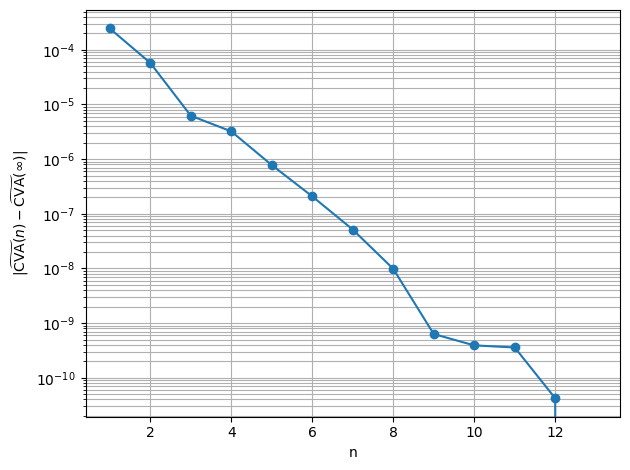

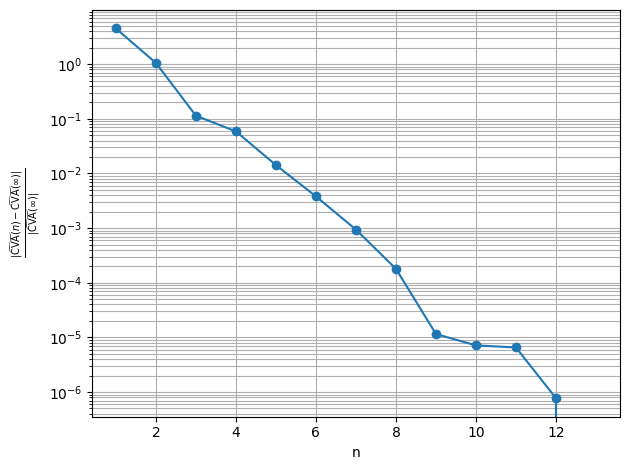

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# inputs:
#   ns       = [1,2,...]   (o np.array)
#   CVA_disc = [CVA_tilde(n) en el mismo orden que ns]
ns = np.array(ns, dtype=int)
CVA_disc = np.array(CVA_disc, dtype=float)

cva_inf = CVA_disc[-1]                 # CVA(∞) ≈ CVA en el mayor n
abs_err = np.abs(CVA_disc - cva_inf)
rel_err = abs_err / np.abs(cva_inf)

plt.figure()
plt.plot(ns, abs_err, marker="o")
plt.yscale("log")
plt.xlabel("n")
plt.ylabel(r"$|\widetilde{\mathrm{CVA}}(n)-\widetilde{\mathrm{CVA}}(\infty)|$")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(ns, rel_err, marker="o")
plt.yscale("log")
plt.xlabel("n")
plt.ylabel(r"$\frac{|\widetilde{\mathrm{CVA}}(n)-\widetilde{\mathrm{CVA}}(\infty)|}{|\widetilde{\mathrm{CVA}}(\infty)|}$")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()
